In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Lasso
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split

[28.55038446]
-3.8808236579870243


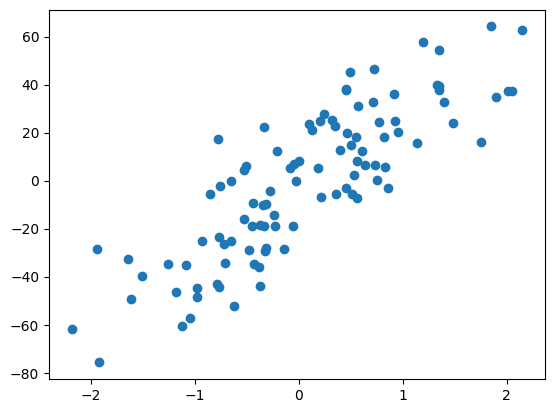

In [2]:
X, y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1, noise=20, random_state=13)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2)

plt.scatter(X, y)

from sklearn.linear_model import LinearRegression

reg = LinearRegression()
reg.fit(X_train, y_train)

print(reg.coef_)
print(reg.intercept_)

C:\Users\Chaittanya Navani\AppData\Roaming\Python\Python314\site-packages\sklearn\base.py:1336: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
C:\Users\Chaittanya Navani\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_coordinate_descent.py:716: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
C:\Users\Chaittanya Navani\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.067e+04, tolerance: 7.549e+00
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implement

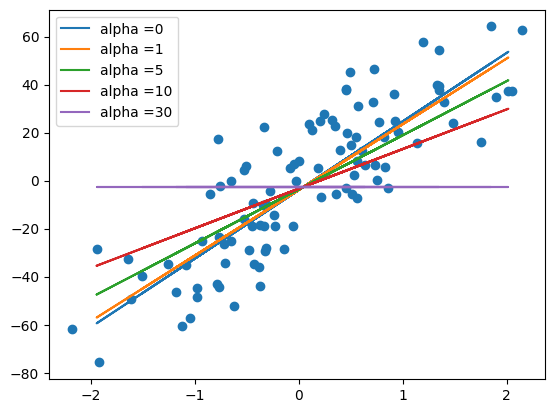

In [3]:
#Applying lasso regression with different values of alpha
alphas = [0, 1, 5, 10, 30] # for 0 - it will behave like a simple linear regression cuz penlaty term will be get zero 
plt.Figure(figsize=(12, 6))
plt.scatter(X, y)
for i in alphas:
    l = Lasso(alpha=i)
    l.fit(X_train, y_train)
    plt.plot(X_test, l.predict(X_test), label = "alpha ={}".format(i))
plt.legend()
plt.show()

In [4]:
# As we can see  when the value of alpha is getting 30 the line of linear regression with alpha = 30 is behaving like underfitting,
#it is due to now the value of penalty term is much greater than loss term 

**One of the most important use of lasso regularizatio/regression (L1) is it can perform Feature selection based on the value of alpha cuz if alpha value is high it will convert some feature's coefficient to zero due to this the value of those feature will automatically become 0 which is indirectly is FEATURE SELECTION**

*1. How are coefficients affected ?*

In [5]:
from sklearn.datasets import load_diabetes
from sklearn.metrics import r2_score


In [6]:
data = load_diabetes()
df = pd.DataFrame(data.data, columns=data.feature_names)
df["Target"] = data.target


In [7]:
df

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,Target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0
...,...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207,178.0
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485,104.0
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491,132.0
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930,220.0


In [8]:
X_Train, X_Test, y_Train, y_Test = train_test_split(data.data, data.target, test_size=0.2, random_state=2)

In [13]:
coefs = []
r2_scores = []

for i in [0, 0.1, 1, 10]:
    L1 = Lasso(alpha=i)
    L1.fit(X_Train, y_Train)

    coefs.append(L1.coef_.tolist())
    y_pred1 = reg.predict(X_test)
    r2_scores.append(r2_score(y_test, y_pred1))

C:\Users\Chaittanya Navani\AppData\Roaming\Python\Python314\site-packages\sklearn\base.py:1336: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
C:\Users\Chaittanya Navani\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_coordinate_descent.py:716: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
C:\Users\Chaittanya Navani\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.967e+05, tolerance: 2.124e+02
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implement

In [14]:
# coefs
r2_scores

[0.6092436299569841,
 0.6092436299569841,
 0.6092436299569841,
 0.6092436299569841]

TypeError: type function doesn't define __round__ method

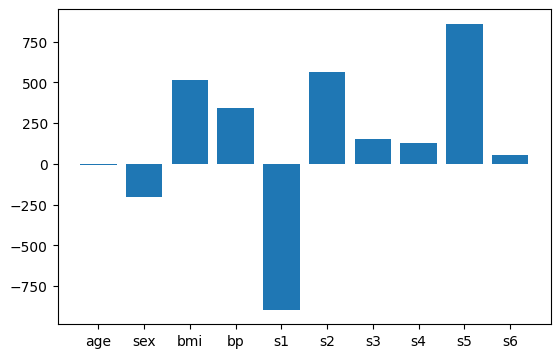

In [11]:
plt.figure(figsize=(14,9))
plt.subplot(221)
plt.bar(data.feature_names,coefs[0])
plt.title('Alpha = 0 ,r2_score = {}'.format(round(r2_scores[0],2)))

plt.subplot(222)
plt.bar(data.feature_names,coefs[1])
plt.title('Alpha = 0.1 ,r2_score = {}'.format(round(r2_scores[1],2)))

plt.subplot(223)
plt.bar(data.feature_names,coefs[2])
plt.title('Alpha = 1 ,r2_score = {}'.format(round(r2_scores[2],2)))

plt.subplot(224)
plt.bar(data.feature_names,coefs[3])
plt.title('Alpha = 10 ,r2_score = {}'.format(round(r2_scores[3],2)))

plt.show()